# 02 — Target Variable Design

## Objective
Evaluate whether a defensible grid-level flood target variable can be constructed for Houston using NOAA Storm Events data.

## Questions
- What flood-related event types are available?
- What temporal fields are available?
- What spatial fields are available?
- Can events be mapped to Houston grid cells in a credible way?

## Candidate Outputs
- Combined raw event table
- Filtered Texas / Houston-area flood-event subset
- Preliminary candidate label table
- Go / no-go decision on target feasibility

## Notes
This notebook is the project feasibility checkpoint. If the target variable is not defensible, the project should not proceed to full feature engineering and modeling.

In [2]:
from pathlib import Path
import sys
import glob

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config import *

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

print_config_summary()

Project: flood-prediction
City: Houston
BBOX: {'lon_min': -95.8, 'lat_min': 29.4, 'lon_max': -95.0, 'lat_max': 30.2}
CRS_GEO: EPSG:4326
CRS_PROJECTED: EPSG:3857
Grid size (m): 1000
Grid file: /Users/suvo/Projects/flood-prediction/data/interim/grids/houston_grid_1km.parquet


In [3]:
event_files = sorted(FLOOD_EVENTS_RAW_DIR.glob("StormEvents_details-ftp_v1.0_d*.csv.gz"))

print("Number of raw event files found:", len(event_files))
for f in event_files:
    print(f.name)

Number of raw event files found: 9
StormEvents_details-ftp_v1.0_d2017_c20260323.csv.gz
StormEvents_details-ftp_v1.0_d2018_c20260323.csv.gz
StormEvents_details-ftp_v1.0_d2019_c20260323.csv.gz
StormEvents_details-ftp_v1.0_d2020_c20260323.csv.gz
StormEvents_details-ftp_v1.0_d2021_c20260323.csv.gz
StormEvents_details-ftp_v1.0_d2022_c20260323.csv.gz
StormEvents_details-ftp_v1.0_d2023_c20260323.csv.gz
StormEvents_details-ftp_v1.0_d2024_c20260323.csv.gz
StormEvents_details-ftp_v1.0_d2025_c20260323.csv.gz


In [4]:
dfs = []

for f in event_files:
    df = pd.read_csv(f, compression="gzip", low_memory=False)
    df["source_file"] = f.name
    dfs.append(df)

events_raw = pd.concat(dfs, ignore_index=True)

print("Combined shape:", events_raw.shape)
events_raw.head()

Combined shape: (597796, 52)


,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,...,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE,source_file
0,201702,28,1752,201702,28,1757,112919,1244230,ILLINOIS,17,...,NNE,DANA,40.9791,-89.0123,41.0002,-88.9307,The late afternoon into the evening of Tuesday...,"A tornado began east of Rutland, producing iso...",CSV,StormEvents_details-ftp_v1.0_d2017_c20260323.c...
1,201704,6,1509,201704,6,1509,113355,678791,NEW JERSEY,34,...,NW,FRIES MILLS,39.6600,-75.0800,39.6600,-75.0800,Low pressure tracked from the Ohio Valley into...,A couple of trees were taken down due to thund...,CSV,StormEvents_details-ftp_v1.0_d2017_c20260323.c...
2,201704,6,930,201704,6,940,113459,679228,FLORIDA,12,...,SW,FORT MYERS VILLAS,26.5010,-81.9980,26.5339,-81.8836,A line of thunderstorms developed along a pref...,Emergency management reported and broadcast me...,CSV,StormEvents_details-ftp_v1.0_d2017_c20260323.c...
3,201704,5,1749,201704,5,1753,113448,679268,OHIO,39,...,NE,FAIRBORN,39.8500,-83.9900,39.8500,-83.9900,Showers and thunderstorms developed ahead of a...,An entire tree was uprooted in a yard on Dayto...,CSV,StormEvents_details-ftp_v1.0_d2017_c20260323.c...
4,201704,16,1759,201704,16,1900,113697,682042,OHIO,39,...,NW,SUMMERSIDE,39.1065,-84.2875,39.1061,-84.2874,Thunderstorms with very heavy rain developed a...,Garage of a home was flooded by high water.,CSV,StormEvents_details-ftp_v1.0_d2017_c20260323.c...


In [5]:
print("Number of columns:", len(events_raw.columns))
events_raw.columns.tolist()

Number of columns: 52


['BEGIN_YEARMONTH',
 'BEGIN_DAY',
 'BEGIN_TIME',
 'END_YEARMONTH',
 'END_DAY',
 'END_TIME',
 'EPISODE_ID',
 'EVENT_ID',
 'STATE',
 'STATE_FIPS',
 'YEAR',
 'MONTH_NAME',
 'EVENT_TYPE',
 'CZ_TYPE',
 'CZ_FIPS',
 'CZ_NAME',
 'WFO',
 'BEGIN_DATE_TIME',
 'CZ_TIMEZONE',
 'END_DATE_TIME',
 'INJURIES_DIRECT',
 'INJURIES_INDIRECT',
 'DEATHS_DIRECT',
 'DEATHS_INDIRECT',
 'DAMAGE_PROPERTY',
 'DAMAGE_CROPS',
 'SOURCE',
 'MAGNITUDE',
 'MAGNITUDE_TYPE',
 'FLOOD_CAUSE',
 'CATEGORY',
 'TOR_F_SCALE',
 'TOR_LENGTH',
 'TOR_WIDTH',
 'TOR_OTHER_WFO',
 'TOR_OTHER_CZ_STATE',
 'TOR_OTHER_CZ_FIPS',
 'TOR_OTHER_CZ_NAME',
 'BEGIN_RANGE',
 'BEGIN_AZIMUTH',
 'BEGIN_LOCATION',
 'END_RANGE',
 'END_AZIMUTH',
 'END_LOCATION',
 'BEGIN_LAT',
 'BEGIN_LON',
 'END_LAT',
 'END_LON',
 'EPISODE_NARRATIVE',
 'EVENT_NARRATIVE',
 'DATA_SOURCE',
 'source_file']

In [6]:
key_cols = [
    "EVENT_ID",
    "STATE",
    "CZ_NAME",
    "EVENT_TYPE",
    "BEGIN_YEARMONTH",
    "BEGIN_DAY",
    "BEGIN_TIME",
    "END_YEARMONTH",
    "END_DAY",
    "END_TIME",
    "BEGIN_LAT",
    "BEGIN_LON",
    "END_LAT",
    "END_LON",
]

available_key_cols = [c for c in key_cols if c in events_raw.columns]

events_raw[available_key_cols].isna().mean().sort_values()

EVENT_ID           0.000000
STATE              0.000000
CZ_NAME            0.000000
EVENT_TYPE         0.000000
BEGIN_YEARMONTH    0.000000
BEGIN_DAY          0.000000
BEGIN_TIME         0.000000
END_YEARMONTH      0.000000
END_DAY            0.000000
END_TIME           0.000000
BEGIN_LAT          0.392279
BEGIN_LON          0.392279
END_LAT            0.392279
END_LON            0.392279
dtype: float64

In [7]:
events_raw["EVENT_TYPE"].unique()

<ArrowStringArray>
[                   'Tornado',          'Thunderstorm Wind',
                      'Flood',                       'Hail',
                'Flash Flood',         'Marine Strong Wind',
           'Marine High Wind',             'Winter Weather',
   'Marine Thunderstorm Wind',                 'Waterspout',
                 'Heavy Rain',                  'Lightning',
               'Funnel Cloud',                  'High Wind',
                 'Heavy Snow',                'Debris Flow',
                    'Drought',                'Strong Wind',
               'Winter Storm',            'Cold/Wind Chill',
        'Hurricane (Typhoon)',              'Coastal Flood',
                   'Wildfire',               'Frost/Freeze',
                   'Blizzard',                  'Ice Storm',
                'Marine Hail',                  'Dense Fog',
    'Extreme Cold/Wind Chill',           'Lake-Effect Snow',
                'Rip Current',                  'High Surf',
     

In [8]:
flood_events = events_raw[
    events_raw["EVENT_TYPE"].isin([
        "Flood",
        "Flash Flood",
        "Coastal Flood"
    ])
].copy()

print("Flood events shape:", flood_events.shape)

Flood events shape: (65991, 52)


In [9]:
tx_events = flood_events[
    flood_events["STATE"] == "TEXAS"
].copy()

print("Texas flood events:", tx_events.shape)

Texas flood events: (3781, 52)


In [10]:
tx_events[["BEGIN_LAT", "BEGIN_LON"]].isna().mean()

BEGIN_LAT    0.017985
BEGIN_LON    0.017985
dtype: float64

In [11]:
houston_events = tx_events[
    (tx_events["BEGIN_LON"] >= BBOX["lon_min"]) &
    (tx_events["BEGIN_LON"] <= BBOX["lon_max"]) &
    (tx_events["BEGIN_LAT"] >= BBOX["lat_min"]) &
    (tx_events["BEGIN_LAT"] <= BBOX["lat_max"])
].copy()

print("Houston flood events:", houston_events.shape)

Houston flood events: (128, 52)


In [12]:
houston_events.head()

,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,...,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE,source_file
6345,201701,18,810,201701,18,1010,112990,675235,TEXAS,48,...,NNW,PASADENA,29.5897,-95.4473,29.7156,-95.2048,A slow moving upper level storm system combine...,There was widespread flooding and numerous roa...,CSV,StormEvents_details-ftp_v1.0_d2017_c20260323.c...
6347,201701,20,1910,201701,20,2015,112974,675098,TEXAS,48,...,NNW,MISSOURI CITY,29.7598,-95.3668,29.6487,-95.5412,Slow moving showers and thunderstorms produced...,There were numerous road closures between the ...,CSV,StormEvents_details-ftp_v1.0_d2017_c20260323.c...
16393,201703,29,1330,201703,29,1530,113876,687225,TEXAS,48,...,WNW,LEAGUE CITY S S ARPT,29.4948,-95.2221,29.4903,-95.1677,A line of thunderstorms moved across southeast...,Street flooding was reported across the Friend...,CSV,StormEvents_details-ftp_v1.0_d2017_c20260323.c...
16394,201703,29,1333,201703,29,1515,113876,687227,TEXAS,48,...,NE,IOWA COLONY,29.5771,-95.3785,29.5215,-95.3854,A line of thunderstorms moved across southeast...,Street flooding was reported across the Pearla...,CSV,StormEvents_details-ftp_v1.0_d2017_c20260323.c...
16609,201703,29,1415,201703,29,1605,113876,687236,TEXAS,48,...,W,GENOA,29.6627,-95.2367,29.6197,-95.2048,A line of thunderstorms moved across southeast...,"Street flooding was reported across the area, ...",CSV,StormEvents_details-ftp_v1.0_d2017_c20260323.c...


In [14]:
grid_gdf = gpd.read_parquet(GRID_FILE)

print("Grid loaded:", grid_gdf.shape)
grid_gdf.head()

Grid loaded: (378, 2)


,grid_id,geometry
0,0,"POLYGON ((-95.75508 29.43912, -95.75508 29.4, ..."
1,1,"POLYGON ((-95.75508 29.47823, -95.75508 29.439..."
2,2,"POLYGON ((-95.75508 29.51733, -95.75508 29.478..."
3,3,"POLYGON ((-95.75508 29.5564, -95.75508 29.5173..."
4,4,"POLYGON ((-95.75508 29.59547, -95.75508 29.556..."


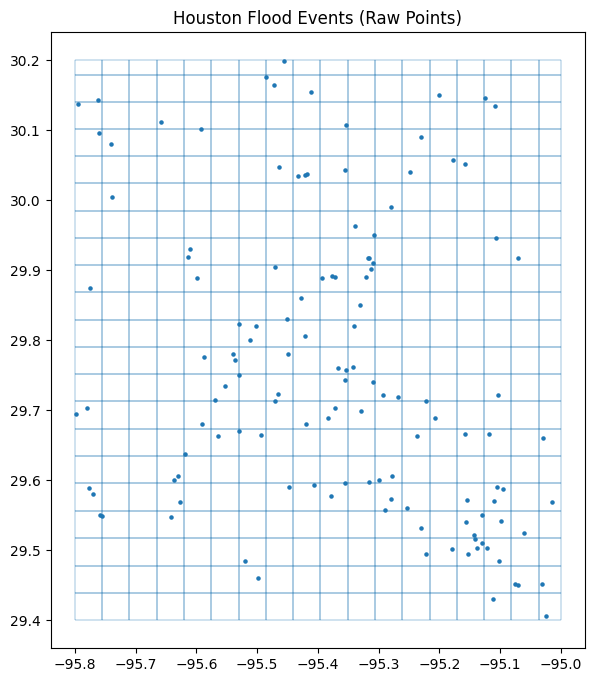

In [40]:
import geopandas as gpd

houston_gdf = gpd.GeoDataFrame(
    houston_events,
    geometry=gpd.points_from_xy(
        houston_events["BEGIN_LON"],
        houston_events["BEGIN_LAT"]
    ),
    crs=CRS_GEO
)

fig, ax = plt.subplots(figsize=(8, 8))

grid_gdf.boundary.plot(ax=ax, linewidth=0.3)
houston_gdf.plot(ax=ax, markersize=5)

ax.set_title("Houston Flood Events (Raw Points)")
fig.savefig("../outputs/figures/houston_flood_events.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
joined = gpd.sjoin(
    houston_gdf,
    grid_gdf,
    how="left",
    predicate="within"
)

print("Joined shape:", joined.shape)
joined.head()

Joined shape: (128, 55)


,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,...,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE,source_file,geometry,index_right,grid_id
6345,201701,18,810,201701,18,1010,112990,675235,TEXAS,48,...,-95.4473,29.7156,-95.2048,A slow moving upper level storm system combine...,There was widespread flooding and numerous roa...,CSV,StormEvents_details-ftp_v1.0_d2017_c20260323.c...,POINT (-95.4473 29.5897),151,151
6347,201701,20,1910,201701,20,2015,112974,675098,TEXAS,48,...,-95.3668,29.6487,-95.5412,Slow moving showers and thunderstorms produced...,There were numerous road closures between the ...,CSV,StormEvents_details-ftp_v1.0_d2017_c20260323.c...,POINT (-95.3668 29.7598),198,198
16393,201703,29,1330,201703,29,1530,113876,687225,TEXAS,48,...,-95.2221,29.4903,-95.1677,A line of thunderstorms moved across southeast...,Street flooding was reported across the Friend...,CSV,StormEvents_details-ftp_v1.0_d2017_c20260323.c...,POINT (-95.2221 29.4948),254,254
16394,201703,29,1333,201703,29,1515,113876,687227,TEXAS,48,...,-95.3785,29.5215,-95.3854,A line of thunderstorms moved across southeast...,Street flooding was reported across the Pearla...,CSV,StormEvents_details-ftp_v1.0_d2017_c20260323.c...,POINT (-95.3785 29.5771),193,193
16609,201703,29,1415,201703,29,1605,113876,687236,TEXAS,48,...,-95.2367,29.6197,-95.2048,A line of thunderstorms moved across southeast...,"Street flooding was reported across the area, ...",CSV,StormEvents_details-ftp_v1.0_d2017_c20260323.c...,POINT (-95.2367 29.6627),258,258


In [17]:
joined["grid_id"].isna().mean()

np.float64(0.0)

In [18]:
grid_event_counts = (
    joined.groupby("grid_id")
    .size()
    .reset_index(name="event_count")
)

grid_event_counts.head()

,grid_id,event_count
0,3,1
1,4,2
2,7,2
3,12,1
4,17,1


In [19]:
grid_with_events = grid_gdf.merge(
    grid_event_counts,
    on="grid_id",
    how="left"
)

grid_with_events["event_count"] = grid_with_events["event_count"].fillna(0)

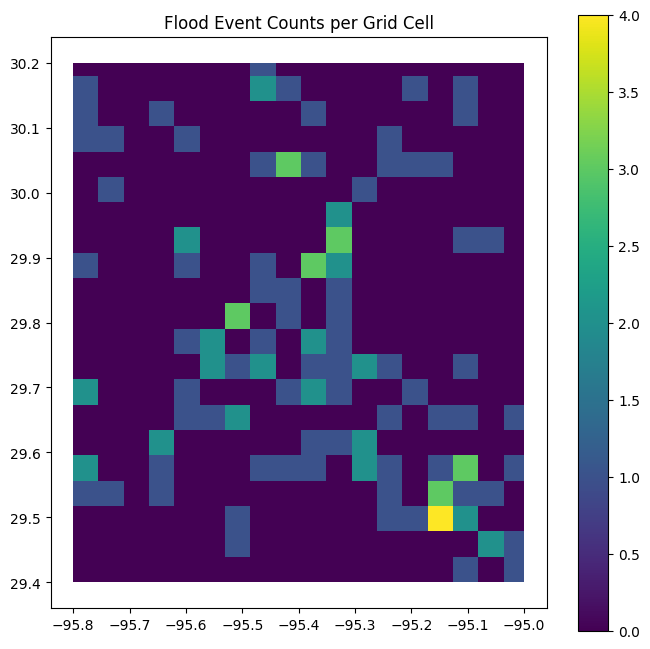

In [20]:
fig, ax = plt.subplots(figsize=(8, 8))

grid_with_events.plot(
    column="event_count",
    ax=ax,
    legend=True
)

ax.set_title("Flood Event Counts per Grid Cell")
plt.show()

In [21]:
tx_events["BEGIN_DATETIME"] = pd.to_datetime(
    tx_events["BEGIN_YEARMONTH"].astype(str) + 
    tx_events["BEGIN_DAY"].astype(str).str.zfill(2),
    format="%Y%m%d"
)

tx_events[["BEGIN_YEARMONTH", "BEGIN_DAY", "BEGIN_DATETIME"]].head()

,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_DATETIME
209,201701,15,2017-01-15
220,201701,15,2017-01-15
1468,201706,1,2017-06-01
1469,201706,1,2017-06-01
1945,201704,10,2017-04-10


In [22]:
houston_events = tx_events[
    (tx_events["BEGIN_LON"] >= BBOX["lon_min"]) &
    (tx_events["BEGIN_LON"] <= BBOX["lon_max"]) &
    (tx_events["BEGIN_LAT"] >= BBOX["lat_min"]) &
    (tx_events["BEGIN_LAT"] <= BBOX["lat_max"])
].copy()

In [23]:
houston_gdf = gpd.GeoDataFrame(
    houston_events,
    geometry=gpd.points_from_xy(
        houston_events["BEGIN_LON"],
        houston_events["BEGIN_LAT"]
    ),
    crs=CRS_GEO
)

In [24]:
joined = gpd.sjoin(
    houston_gdf,
    grid_gdf,
    how="left",
    predicate="within"
)

In [25]:
event_table = joined[[
    "grid_id",
    "BEGIN_DATETIME"
]].dropna().copy()

event_table.head()

,grid_id,BEGIN_DATETIME
6345,151,2017-01-18
6347,198,2017-01-20
16393,254,2017-03-29
16394,193,2017-03-29
16609,258,2017-03-29


In [26]:
date_range = pd.date_range(
    start=event_table["BEGIN_DATETIME"].min(),
    end=event_table["BEGIN_DATETIME"].max(),
    freq="D"
)

grid_ids = grid_gdf["grid_id"].unique()

full_index = pd.MultiIndex.from_product(
    [grid_ids, date_range],
    names=["grid_id", "date"]
)

labels = pd.DataFrame(index=full_index).reset_index()

In [27]:
event_days = event_table.copy()
event_days = event_days.rename(columns={"BEGIN_DATETIME": "date"})
event_days["label"] = 1

labels = labels.merge(
    event_days,
    on=["grid_id", "date"],
    how="left"
)

labels["label"] = labels["label"].fillna(0)

In [30]:
labels = labels.sort_values(["grid_id", "date"])

labels["label_7d"] = (
    labels.groupby("grid_id")["label"]
    .rolling(window=7, min_periods=1)
    .max()
    .reset_index(level=0, drop=True)
)

In [32]:
labels["label_7d"].mean()

np.float64(0.0007084349134877435)

In [33]:
# buffer events by ~5 km (same as grid size)
houston_gdf_buffered = houston_gdf.copy()
houston_gdf_buffered = houston_gdf_buffered.to_crs(CRS_PROJECTED)

houston_gdf_buffered["geometry"] = houston_gdf_buffered.buffer(5000)

houston_gdf_buffered = houston_gdf_buffered.to_crs(CRS_GEO)

In [34]:
joined_buffered = gpd.sjoin(
    houston_gdf_buffered,
    grid_gdf,
    how="left",
    predicate="intersects"
)

In [35]:
event_table = joined_buffered[[
    "grid_id",
    "BEGIN_DATETIME"
]].dropna().copy()

In [36]:
labels["label_14d"] = (
    labels.groupby("grid_id")["label"]
    .rolling(window=14, min_periods=1)
    .max()
    .reset_index(level=0, drop=True)
)

In [37]:
labels["label_14d"].mean()

np.float64(0.0014084660913469256)

In [38]:
tx_events.to_parquet(
    INTERIM_DIR / "labels" / "tx_flood_events.parquet",
    index=False
)

In [39]:
houston_events.to_parquet(
    INTERIM_DIR / "labels" / "houston_flood_events.parquet",
    index=False
)